# Customer Churn Prediction Project – Progress Submission
**Dataset:** IBM Telco Customer Churn Dataset  
**Project Title:** Customer Churn Prediction using Machine Learning and Deep Learning

This notebook is submitted as the **data analysis / progress update** for the project.  
It focuses on:
- loading and understanding the dataset
- cleaning the data
- exploratory data analysis (EDA)
- identifying early patterns related to customer churn
- preparing the data for the next phase of modeling



## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load the Dataset
The selected dataset for this project is the **IBM Telco Customer Churn** dataset from Kaggle.

In [2]:
file_path = "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
display(df.head())

Dataset loaded successfully.
Shape of dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Initial Understanding of the Data


In [3]:
print("Column Names:")
print(list(df.columns))
print("\nData Types:")
display(df.dtypes)
print("\nBasic Info:")
df.info()

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

In [4]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning

The dataset contains a column called `TotalCharges` which is often stored as text because of blank values.
We convert it to numeric and check for missing values.

In [5]:
# Remove customerID from analysis because it is only an identifier
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values before handling:")
display(df.isnull().sum().sort_values(ascending=False))

Missing values before handling:


,0
TotalCharges,11
gender,0
Partner,0
SeniorCitizen,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0
OnlineBackup,0


In [6]:
# Drop rows with missing TotalCharges values
df = df.dropna().reset_index(drop=True)

print("Shape after dropping missing rows:", df.shape)
print("\nMissing values after handling:")
display(df.isnull().sum().sort_values(ascending=False))

Shape after dropping missing rows: (7032, 20)

Missing values after handling:


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


### Observation
- `TotalCharges` needed conversion to numeric.
- A small number of rows had missing values and were removed.
- After cleaning, the dataset is ready for exploratory analysis.

## 5. Target Variable Analysis – Churn
We check how many customers stayed and how many churned.

,Count,Percentage
Churn,,
No,5163,73.42
Yes,1869,26.58


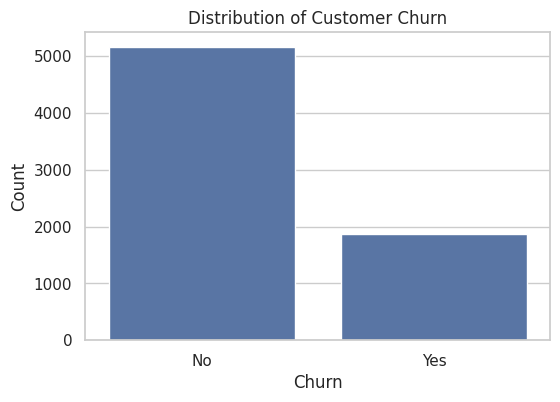

In [7]:
churn_counts = df["Churn"].value_counts()
churn_percent = df["Churn"].value_counts(normalize=True) * 100

display(pd.DataFrame({
    "Count": churn_counts,
    "Percentage": churn_percent.round(2)
}))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

### Observation
The dataset is **slightly imbalanced**, with more customers in the **No churn** class than the **Yes churn** class.  
This is still suitable for machine learning, but class balance should be considered during model evaluation.

## 6. Understand Numerical Features
We analyze the main numeric variables:
- `tenure`
- `MonthlyCharges`
- `TotalCharges`

In [8]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


### Distribution of `tenure`

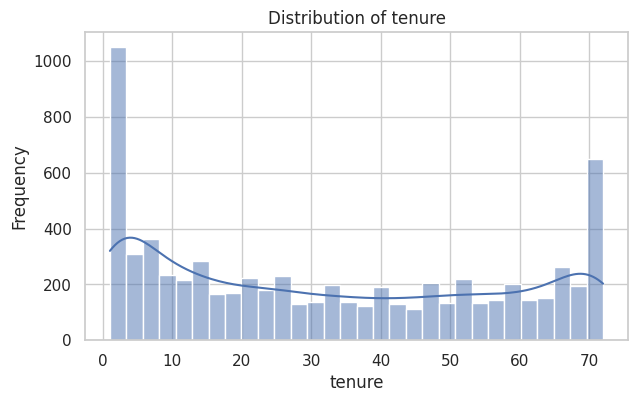

In [9]:
plt.figure(figsize=(7,4))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Distribution of tenure")
plt.xlabel("tenure")
plt.ylabel("Frequency")
plt.show()

### Distribution of `MonthlyCharges`

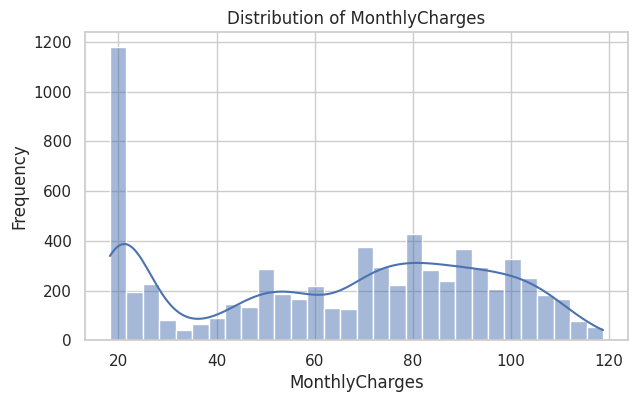

In [10]:
plt.figure(figsize=(7,4))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Distribution of MonthlyCharges")
plt.xlabel("MonthlyCharges")
plt.ylabel("Frequency")
plt.show()

### Distribution of `TotalCharges`

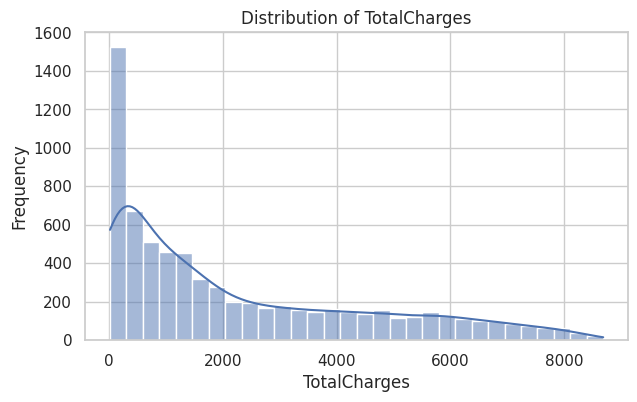

In [11]:
plt.figure(figsize=(7,4))
sns.histplot(df["TotalCharges"], bins=30, kde=True)
plt.title("Distribution of TotalCharges")
plt.xlabel("TotalCharges")
plt.ylabel("Frequency")
plt.show()

### Observation
- `tenure` shows how long customers stayed with the company.
- `MonthlyCharges` captures monthly billing behavior.
- `TotalCharges` increases with time and service usage, so it can be an important churn indicator.

## 7. Churn vs Numerical Features
We compare numerical variables across churn classes.

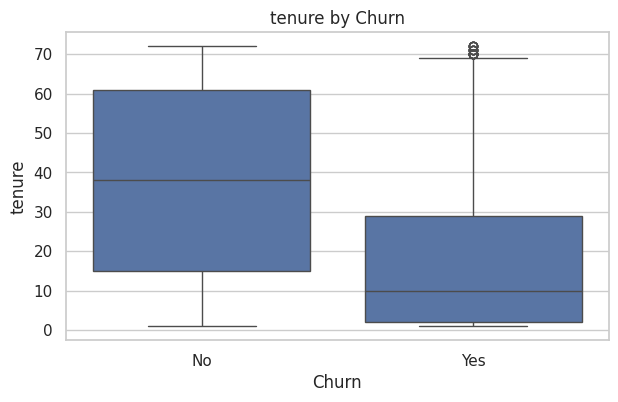

In [12]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("tenure by Churn")
plt.show()

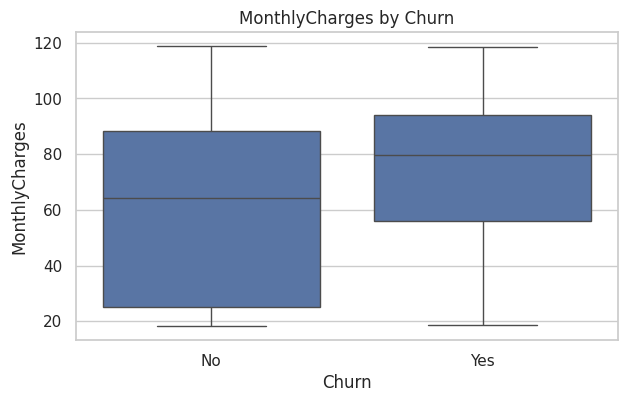

In [13]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("MonthlyCharges by Churn")
plt.show()

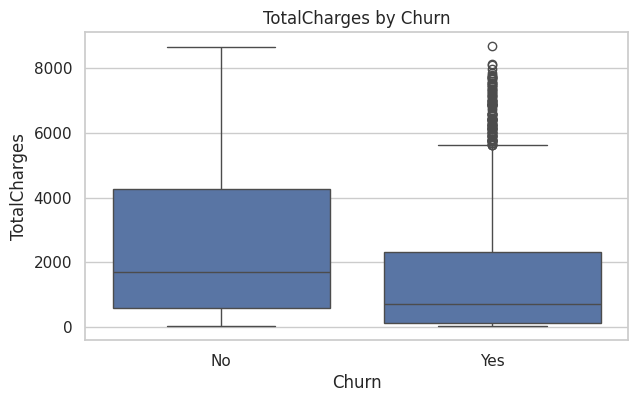

In [14]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("TotalCharges by Churn")
plt.show()

### Early Insights from Numerical Features
- Customers with **lower tenure** tend to churn more.
- Customers with **higher monthly charges** often show higher churn.
- `TotalCharges` should be interpreted together with `tenure`, since long-term customers naturally accumulate larger total charges.

## 8. Categorical Feature Analysis
We check important categorical variables and how they relate to churn.

### `gender` vs Churn

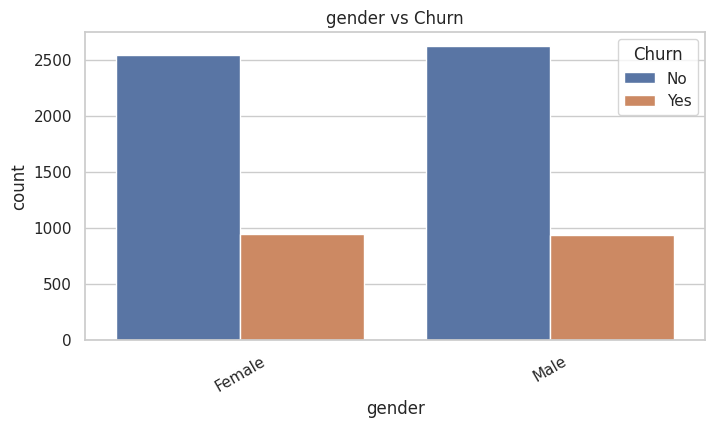

In [15]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("gender vs Churn")
plt.xticks(rotation=30)
plt.show()

### `SeniorCitizen` vs Churn

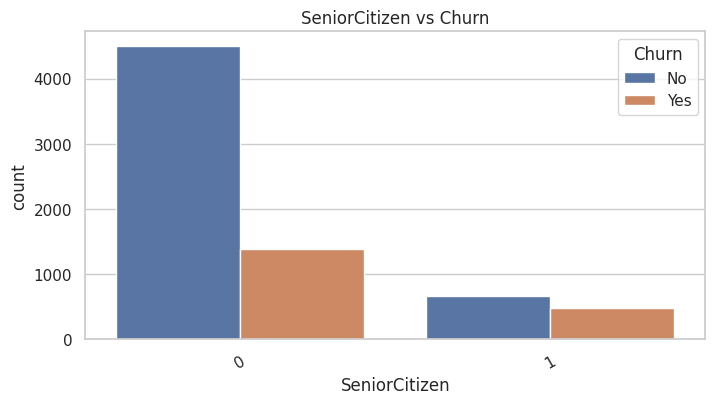

In [16]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("SeniorCitizen vs Churn")
plt.xticks(rotation=30)
plt.show()

### `Partner` vs Churn

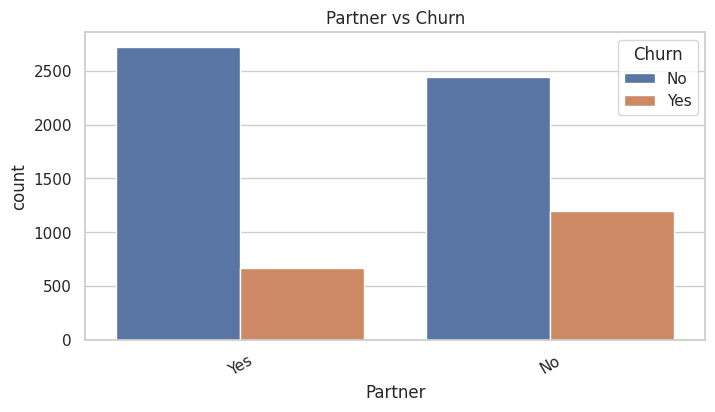

In [17]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Partner", hue="Churn")
plt.title("Partner vs Churn")
plt.xticks(rotation=30)
plt.show()

### `Dependents` vs Churn

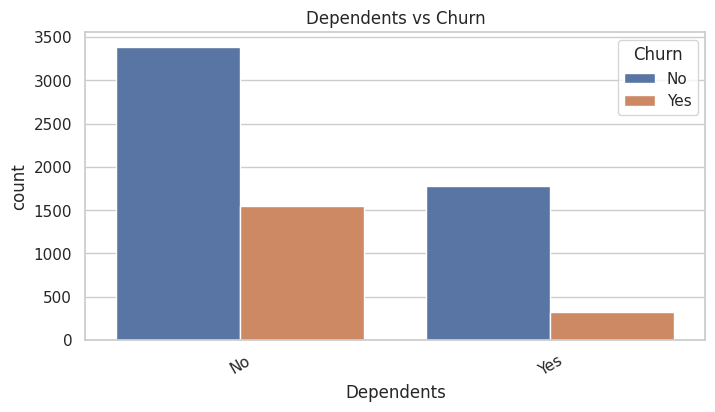

In [18]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Dependents", hue="Churn")
plt.title("Dependents vs Churn")
plt.xticks(rotation=30)
plt.show()

### `PhoneService` vs Churn

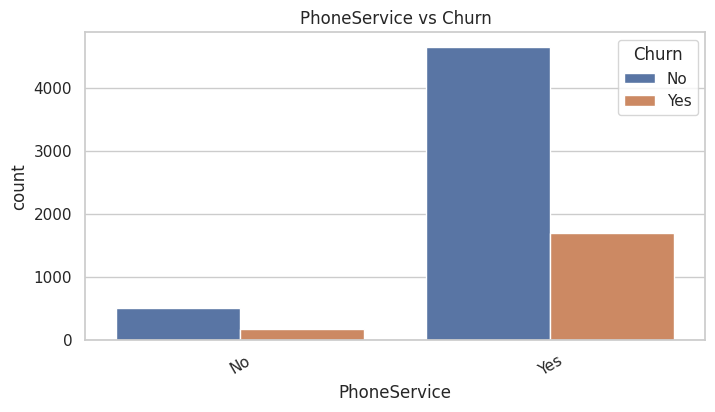

In [19]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="PhoneService", hue="Churn")
plt.title("PhoneService vs Churn")
plt.xticks(rotation=30)
plt.show()

### `InternetService` vs Churn

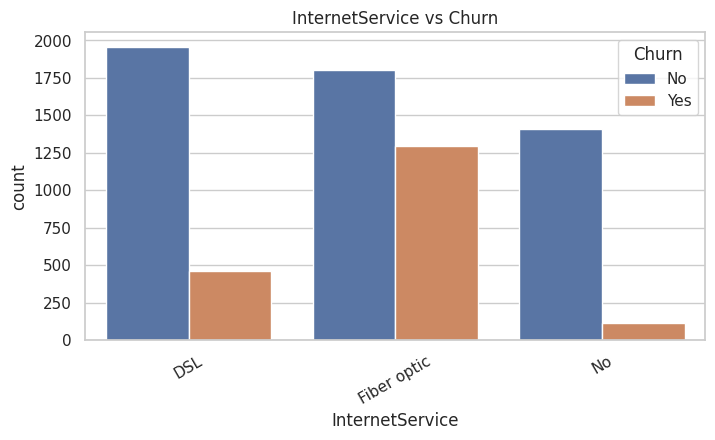

In [20]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("InternetService vs Churn")
plt.xticks(rotation=30)
plt.show()

### `OnlineSecurity` vs Churn

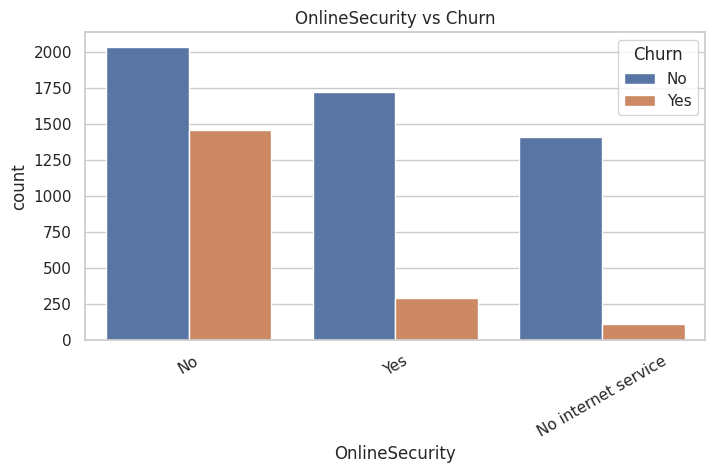

In [21]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="OnlineSecurity", hue="Churn")
plt.title("OnlineSecurity vs Churn")
plt.xticks(rotation=30)
plt.show()

### `TechSupport` vs Churn

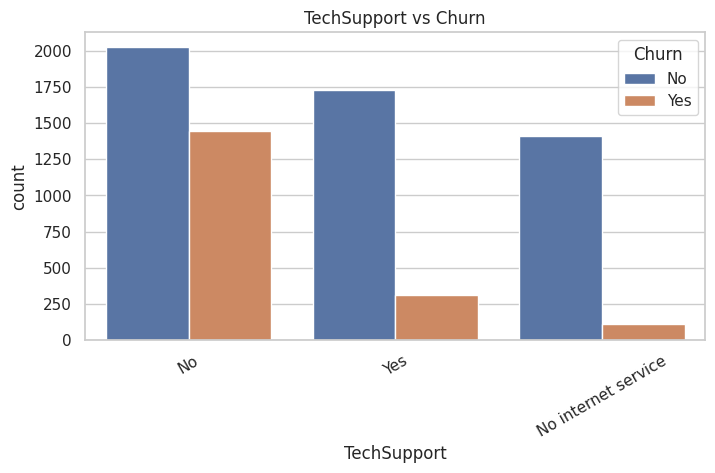

In [22]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="TechSupport", hue="Churn")
plt.title("TechSupport vs Churn")
plt.xticks(rotation=30)
plt.show()

### `Contract` vs Churn

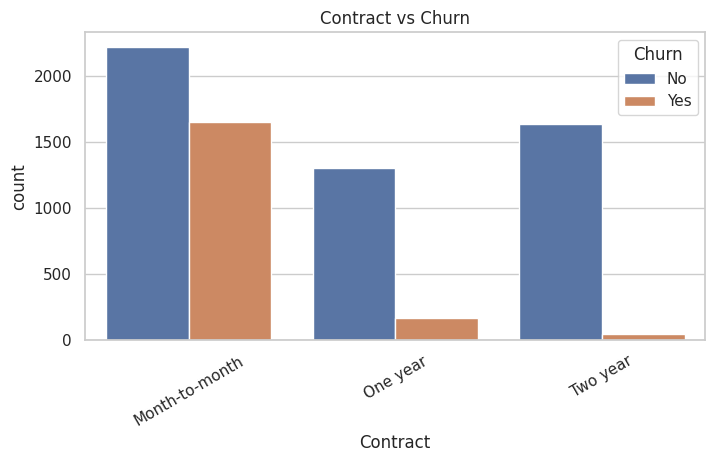

In [23]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract vs Churn")
plt.xticks(rotation=30)
plt.show()

### `PaperlessBilling` vs Churn

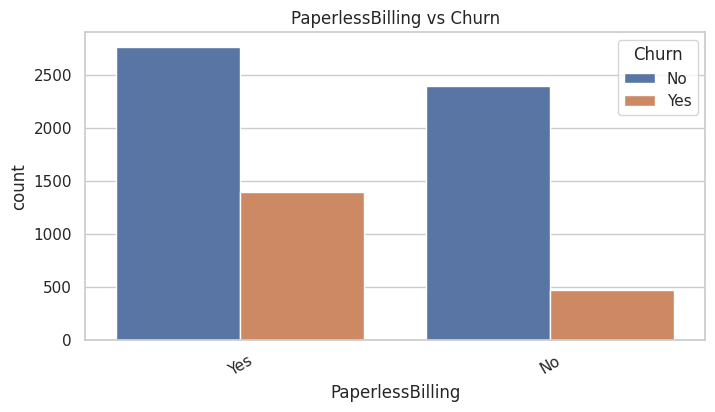

In [24]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="PaperlessBilling", hue="Churn")
plt.title("PaperlessBilling vs Churn")
plt.xticks(rotation=30)
plt.show()

### `PaymentMethod` vs Churn

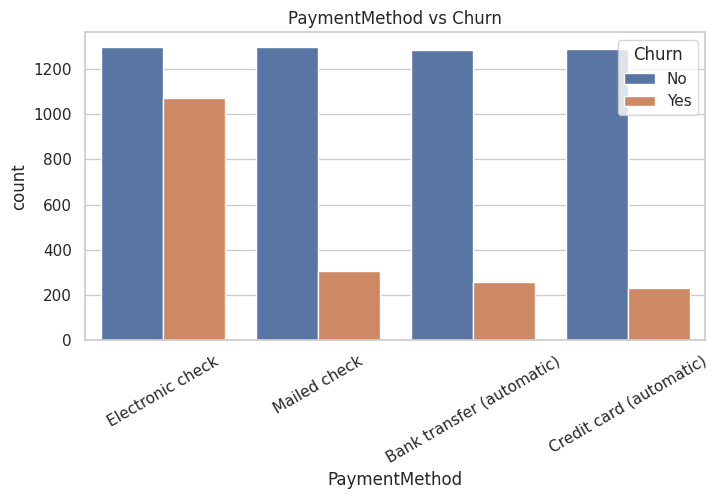

In [25]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("PaymentMethod vs Churn")
plt.xticks(rotation=30)
plt.show()

### Early Insights from Categorical Features
From the charts, some strong churn patterns usually appear:
- Customers on **month-to-month contracts** churn more than customers on one-year or two-year contracts.
- Customers without **online security** or **tech support** tend to churn more.
- Customers using **electronic check** often show higher churn.
- Customers with longer-term service relationships and bundled services appear more stable.

## 9. Churn Rate by Selected Features
To make patterns easier to interpret, we calculate churn percentages for selected categorical columns.

In [26]:
def churn_rate_table(column):
    temp = pd.crosstab(df[column], df["Churn"], normalize="index") * 100
    if "Yes" in temp.columns:
        temp = temp[["Yes"]].rename(columns={"Yes": "ChurnRate(%)"})
    return temp.sort_values(by="ChurnRate(%)", ascending=False)

selected_cols = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]

for col in selected_cols:
    print(f"\nChurn rate by {col}")
    display(churn_rate_table(col))


Churn rate by Contract


Churn,ChurnRate(%)
Contract,
Month-to-month,42.709677
One year,11.277174
Two year,2.848665



Churn rate by InternetService


Churn,ChurnRate(%)
InternetService,
Fiber optic,41.892765
DSL,18.998344
No,7.434211



Churn rate by PaymentMethod


Churn,ChurnRate(%)
PaymentMethod,
Electronic check,45.285412
Mailed check,19.201995
Bank transfer (automatic),16.731518
Credit card (automatic),15.253123



Churn rate by OnlineSecurity


Churn,ChurnRate(%)
OnlineSecurity,
No,41.778667
Yes,14.640199
No internet service,7.434211



Churn rate by TechSupport


Churn,ChurnRate(%)
TechSupport,
No,41.647465
Yes,15.196078
No internet service,7.434211


## 10. Correlation Analysis
Only numeric features can be used in a standard correlation heatmap.

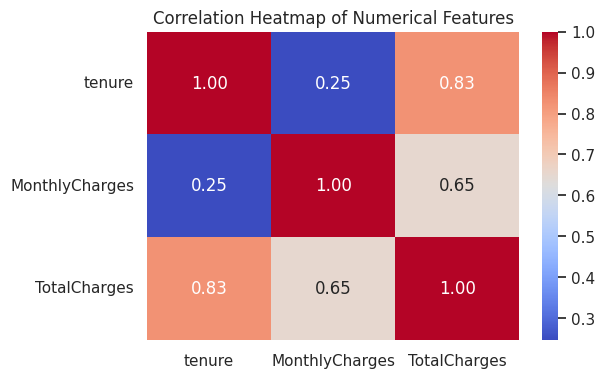

In [27]:
plt.figure(figsize=(6,4))
corr = df[["tenure", "MonthlyCharges", "TotalCharges"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Observation
- `TotalCharges` is strongly related to `tenure`, which is expected because total charges accumulate over time.
- `MonthlyCharges` and `tenure` offer useful but different information, so both can help in prediction.

## 11. Optional Encoding Preview for Modeling
This section shows how the dataset can be prepared for the next phase (machine learning and deep learning).

In [28]:
# Convert target to binary for future modeling
df_model = df.copy()
df_model["Churn"] = df_model["Churn"].map({"No": 0, "Yes": 1})

# One-hot encode categorical features
df_encoded = pd.get_dummies(df_model, drop_first=True)

print("Encoded dataset shape:", df_encoded.shape)
display(df_encoded.head())

Encoded dataset shape: (7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


## 12. Summary of Findings
### Key Findings from the Data Analysis
1. The dataset is clean after handling the `TotalCharges` issue.
2. The target variable (`Churn`) is slightly imbalanced but workable.
3. Customers with **month-to-month contracts** appear more likely to churn.
4. Customers with **shorter tenure** are more likely to leave.
5. Customers with **higher monthly charges** show higher churn risk.
6. Certain service-related features such as **OnlineSecurity** and **TechSupport** appear important.
7. The dataset is suitable for both **traditional machine learning models** and a **simple neural network**.

### How this supports the project
This analysis confirms that the chosen dataset is appropriate for the proposed project:
- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine
- Neural Network using PyTorch

The next step is feature preparation, train-test splitting, model training, and performance comparison using:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

## 13. Progress Update / Issues Faced
### Issues Faced
At this stage, no major blocker prevents the project from moving forward.  
One minor issue was that the `TotalCharges` column contained non-numeric values / blanks, which required conversion to numeric and removal of missing rows.

